# 01 — Keşifsel Veri Analizi (EDA)

Bu notebook, kredi kartı dolandırıcılığı veri setini modelleme öncesi anlamak için hazırlanmıştır.

## Bu notebookun amacı

- Veri yapısını hızlıca doğrulamak (satır/sütun, tipler, eksik değer)
- Hedef değişkenin (`Class`) dengesizliğini ölçmek
- `Amount` ve `Time` gibi ana değişkenlerin dağılımını incelemek
- Hedef değişken ile temel ilişkileri görmek (korelasyon)

## Beklenen çıktı

Bu analiz sonunda şu sorulara net cevap verebiliyor olacağız:

1. Veri temiz mi, eksik değer var mı?
2. Sınıf dengesizliği ne kadar ciddi?
3. Hangi değişkenler hedefle daha ilişkili görünüyor?
4. Baseline model için hangi ön işleme adımları gerekli olabilir?

In [1]:
import sys
from pathlib import Path

# Proje kökü: notebooks/ -> bir üst dizin
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from fraud_detection.paths import DEFAULT_DATA_PATH

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1) Veriyi yükleme ve ilk kontrol

Bu bölümde veri dosyasının gerçekten mevcut olduğunu doğruluyor ve DataFrame'i belleğe alıyoruz.

- Dosya yoksa `assert` ile erken hata verip süreci durdururuz.
- `shape` ve `head()` ile temel yapıyı hızlıca görürüz.

Not: Veri dosyası yolu `src/fraud_detection/paths.py` içindeki `DEFAULT_DATA_PATH` üzerinden gelir.

In [2]:
assert DEFAULT_DATA_PATH.exists(), f"Veri bulunamadı: {DEFAULT_DATA_PATH} — data/README.md talimatlarına bakın."

df = pd.read_csv(DEFAULT_DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2) Şema ve veri kalitesi

Önce veri tiplerini ve null durumunu kontrol ediyoruz.

- `df.info()` sütun tiplerini, toplam satır sayısını ve null durumunu verir.
- Eksik değer analizi, modelleme öncesi temizleme ihtiyacını gösterir.

Yorumlama:
- Eğer eksik değer yoksa bu veri setinde imputasyon adımı zorunlu olmayabilir.
- Uygun olmayan tip varsa (ör. sayısal olması gereken object), dönüşüm gerekir.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

## 3) Hedef değişken analizi (`Class`)

Bu veri seti tipik olarak **aşırı dengesiz**dir. Önce bunu nicel olarak görüyoruz.

- Sınıf adetleri (`value_counts`) veri dengesini gösterir.
- Yüzde dağılımı, dengesizliğin ciddiyetini daha anlaşılır hale getirir.

Yorumlama:
- Fraud oranı çok düşükse, doğruluk (accuracy) tek başına yanıltıcı olur.
- İleride `precision`, `recall`, `PR-AUC` gibi metriklere odaklanmak gerekir.

In [5]:
class_counts = df["Class"].value_counts().sort_index()
class_ratio = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class counts:\n", class_counts)
print("\nClass ratio (%):\n", class_ratio.round(4))

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class ratio (%):
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


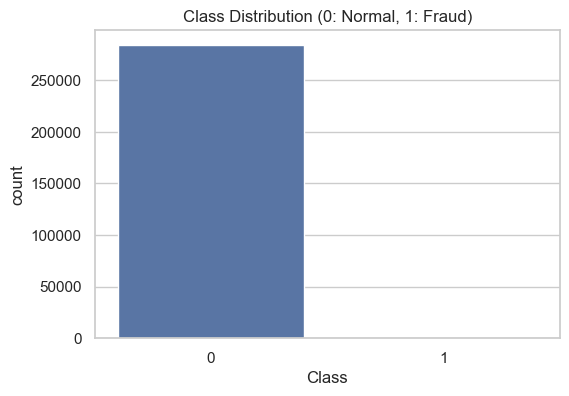

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.show()

## 4) `Amount` ve `Time` dağılım analizi

Bu bölümde işlem tutarı ve zaman değişkenini inceliyoruz.

- `Amount` genelde sağa çarpık olur; bu yüzden `log1p` dönüşümü eklenir.
- `Time` dağılımı veri toplama penceresi hakkında fikir verir.
- `Class` bazında `Amount` kutu grafiği, sınıflar arası farkı görselleştirir.

Yorumlama:
- Güçlü çarpıklık varsa ölçekleme/dönüşüm model performansına katkı sağlar.
- Sınıflar arası ayrım zayıfsa tek değişkenle ayrıştırma zor olabilir; çok değişkenli model gerekir.

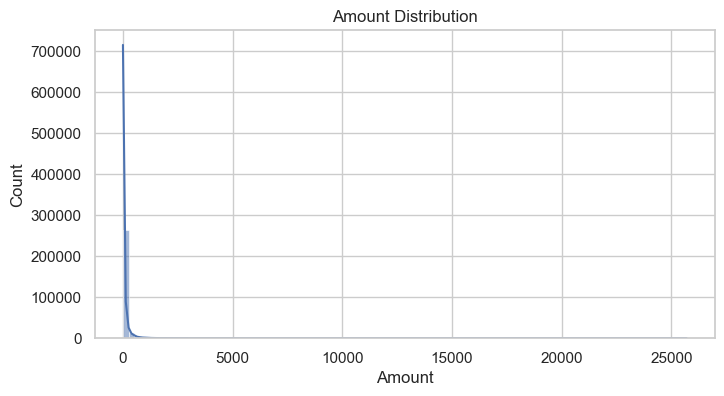

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Amount"], bins=100, kde=True)
plt.title("Amount Distribution")
plt.show()

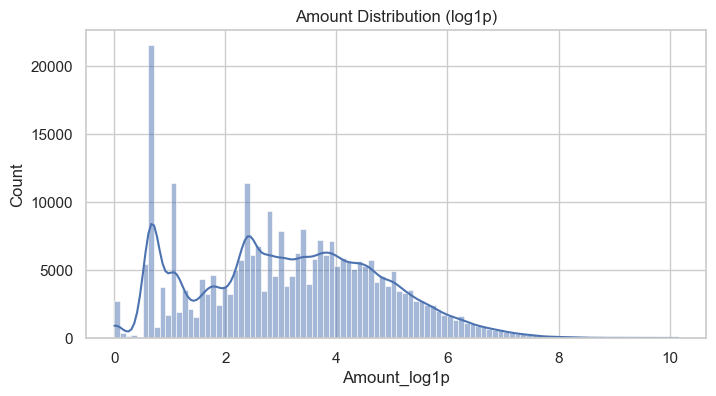

In [8]:
df["Amount_log1p"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 4))
sns.histplot(df["Amount_log1p"], bins=100, kde=True)
plt.title("Amount Distribution (log1p)")
plt.show()

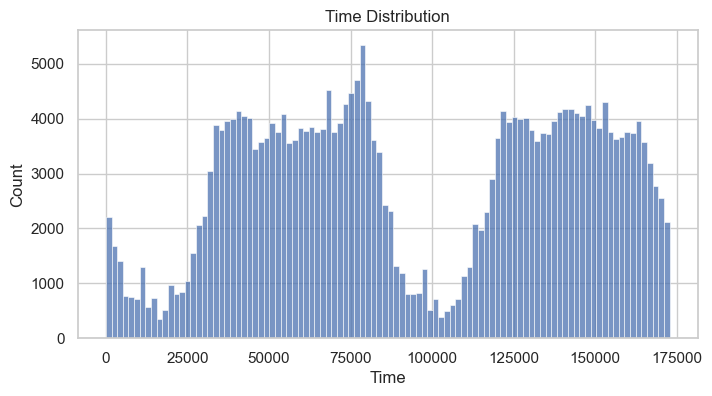

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Time"], bins=100, kde=False)
plt.title("Time Distribution")
plt.show()

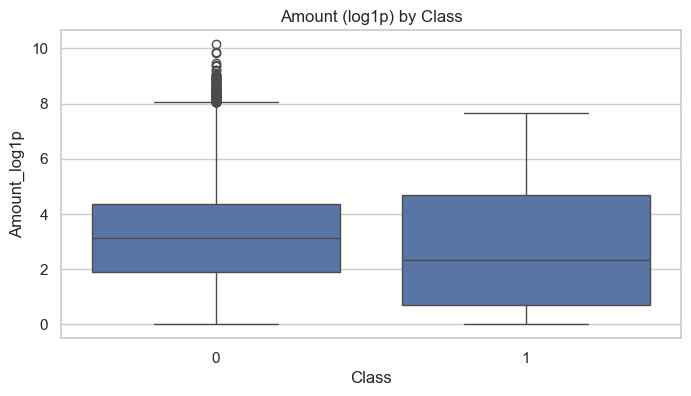

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Class", y="Amount_log1p", data=df)
plt.title("Amount (log1p) by Class")
plt.show()

## 5) İstatistiksel özet ve hedefle ilişki

Son bölümde:

- `describe()` ile temel istatistikleri özetliyoruz.
- `Class` ile korelasyon sıralaması çıkararak ilk sinyal aldığımız değişkenleri görüyoruz.

Yorumlama:
- Korelasyon nedensellik değildir; yalnızca ilk yönlendirme verir.
- Modelleme aşamasında çapraz doğrulama ile gerçek katkı test edilmelidir.

In [11]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [12]:
corr_with_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)

print("Top positive correlations with Class:")
print(corr_with_target.head(10))
print("\nTop negative correlations with Class:")
print(corr_with_target.tail(10))

Top positive correlations with Class:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top negative correlations with Class:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


## 6) M2 başlangıcı: train/test split (stratify)

Bu adımda hedef değişkeni (`Class`) koruyarak veriyi ayırıyoruz.

- `stratify=y` sayesinde train ve test setlerinde fraud oranı benzer kalır.
- Aşırı dengesiz veri setlerinde bu kritik bir best practice'tir.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud ratio (%):", round((y_train.mean() * 100), 6))
print("Test fraud ratio (%):", round((y_test.mean() * 100), 6))

Train shape: (227845, 31)
Test shape: (56962, 31)
Train fraud ratio (%): 0.172925
Test fraud ratio (%): 0.172045


## 7) İki baseline pipeline: StandardScaler vs RobustScaler

Aynı modeli (`LogisticRegression`) iki farklı ölçekleyici ile kurup ilk karşılaştırmayı yapıyoruz.

- `StandardScaler`: ortalama/standart sapma ile ölçekler
- `RobustScaler`: medyan/IQR ile ölçekler (outlier'lara daha dayanıklı)

Not: Bu hücrede sadece pipeline'ları kuruyoruz; değerlendirmeyi bir sonraki adımda yapacağız.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression

standard_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

robust_pipeline = Pipeline(
    steps=[
        ("scaler", RobustScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

print("Pipelines hazır:", ["standard_pipeline", "robust_pipeline"])

Pipelines hazır: ['standard_pipeline', 'robust_pipeline']


In [15]:
# Hızlı fit (sadece bu adım için)
standard_pipeline.fit(X_train, y_train)
robust_pipeline.fit(X_train, y_train)

print("Fit tamamlandı.")

Fit tamamlandı.


## 8) Pipeline değerlendirme (aynı metrik seti)

Bu bölümde `standard_pipeline` ve `robust_pipeline` modellerini aynı test seti üzerinde karşılaştırıyoruz.

Odak metrikler:
- `PR-AUC (Average Precision)`
- `ROC-AUC`
- `Precision`, `Recall`, `F1` (fraud sınıfı için)

Not: Dengesiz veri nedeniyle tek başına accuracy'ye güvenmiyoruz.

In [16]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

models = {
    "StandardScaler + LR": standard_pipeline,
    "RobustScaler + LR": robust_pipeline,
}

results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

    results.append(
        {
            "model": name,
            "PR_AUC": average_precision_score(y_test, y_proba),
            "ROC_AUC": roc_auc_score(y_test, y_proba),
            "Precision@0.5": precision_score(y_test, y_pred, zero_division=0),
            "Recall@0.5": recall_score(y_test, y_pred, zero_division=0),
            "F1@0.5": f1_score(y_test, y_pred, zero_division=0),
        }
    )

results_df = pd.DataFrame(results).sort_values(by="PR_AUC", ascending=False)
results_df.round(6)

,model,PR_AUC,ROC_AUC,Precision@0.5,Recall@0.5,F1@0.5
0,StandardScaler + LR,0.71943,0.971852,0.061183,0.918367,0.114723
1,RobustScaler + LR,0.71608,0.971828,0.061433,0.918367,0.115163


In [17]:
best_model_name = results_df.iloc[0]["model"]
print("Best model by PR_AUC:", best_model_name)

y_pred_best = predictions[best_model_name]["y_pred"]
print("\nClassification report (best model):")
print(classification_report(y_test, y_pred_best, digits=4))

Best model by PR_AUC: StandardScaler + LR

Classification report (best model):
              precision    recall  f1-score   support

           0     0.9999    0.9757    0.9876     56864
           1     0.0612    0.9184    0.1147        98

    accuracy                         0.9756     56962
   macro avg     0.5305    0.9470    0.5512     56962
weighted avg     0.9982    0.9756    0.9861     56962



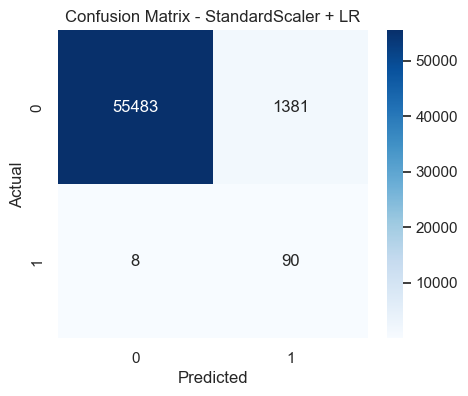

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

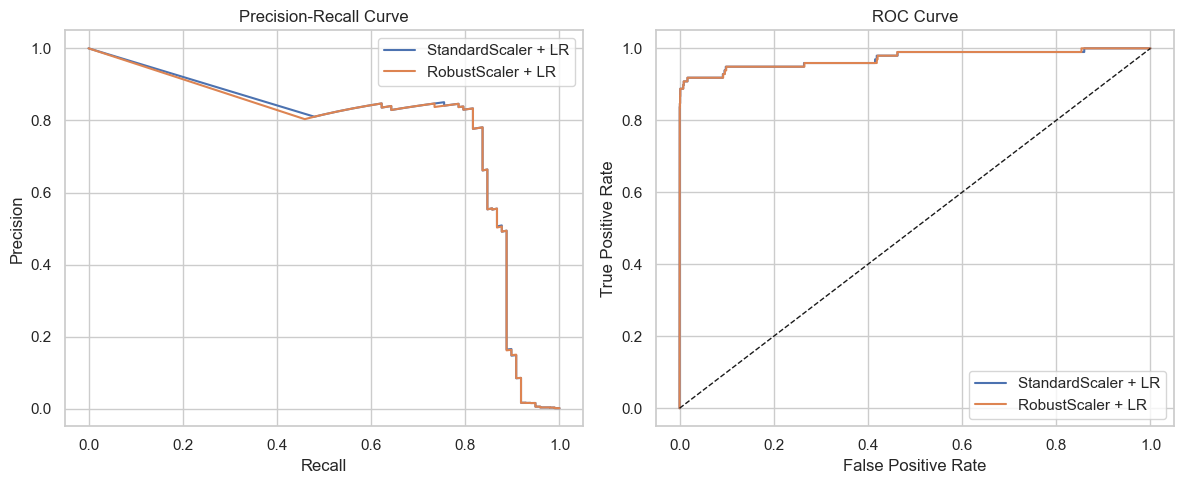

In [19]:
from sklearn.metrics import precision_recall_curve, roc_curve

plt.figure(figsize=(12, 5))

# Precision-Recall curves
plt.subplot(1, 2, 1)
for name in models:
    y_proba = predictions[name]["y_proba"]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# ROC curves
plt.subplot(1, 2, 2)
for name in models:
    y_proba = predictions[name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

## 9) Threshold tuning (F1 maksimize)

Bu bölümde en iyi baseline modelin olasılık çıktısını (`predict_proba`) kullanarak, `precision_recall_curve` üzerinden F1 skorunu maksimize eden en iyi eşiği buluyoruz.

In [22]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

# PR_AUC'e göre seçilen en iyi modelin olasılıkları
best_proba = predictions[best_model_name]["y_proba"]

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)

# thresholds uzunluğu precision/recall'dan 1 eksiktir
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision[:-1][best_idx]
best_recall = recall[:-1][best_idx]

print(f"Best model: {best_model_name}")
print(f"Best threshold (max F1): {best_threshold:.6f}")
print("Best threshold raw value:", repr(float(best_threshold)))
print(f"Precision @ best threshold: {best_precision:.6f}")
print(f"Recall @ best threshold: {best_recall:.6f}")
print(f"F1 @ best threshold: {best_f1:.6f}")

# Yeni eşik ile tahmin
y_pred_opt = (best_proba >= best_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
print("\nConfusion matrix @ best threshold:")
print(cm_opt)

Best model: StandardScaler + LR
Best threshold (max F1): 1.000000
Best threshold raw value: 0.9999999462671703
Precision @ best threshold: 0.833333
Recall @ best threshold: 0.816327
F1 @ best threshold: 0.824742

Confusion matrix @ best threshold:
[[56848    16]
 [   18    80]]


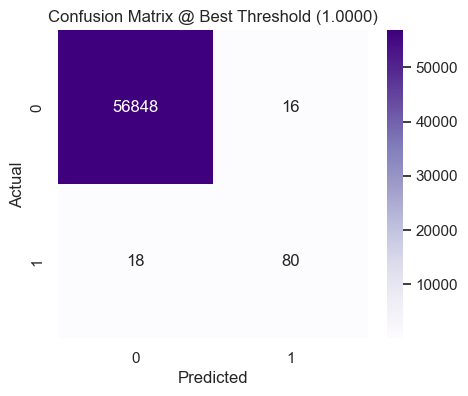

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Purples")
plt.title(f"Confusion Matrix @ Best Threshold ({best_threshold:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10) Threshold karşılaştırma tablosu

Bu tablo, farklı eşiklerde model davranışını karşılaştırır. İş hedefinize göre uygun eşiği seçmek için kullanın.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

threshold_grid = [0.20, 0.40, 0.60, 0.80, float(best_threshold)]
rows = []

for t in threshold_grid:
    y_pred_t = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    rows.append(
        {
            "threshold": round(float(t), 6),
            "precision": precision_score(y_test, y_pred_t, zero_division=0),
            "recall": recall_score(y_test, y_pred_t, zero_division=0),
            "f1": f1_score(y_test, y_pred_t, zero_division=0),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "alerts(tp+fp)": int(tp + fp),
        }
    )

threshold_eval_df = pd.DataFrame(rows).sort_values(by="threshold")
threshold_eval_df.round(6)